# RetinaVLM: Vision Encoder → Projection → LLM 실험 노트북

**공개된 pretrained 가중치를 HuggingFace에서 자동 다운로드하여 사용합니다.**

```
OCT Image (1, 192, 192)
  → [ResNet50 Vision Encoder]  → Vision Tokens (36, 2048)
  → [Linear Projection]       → Projected     (36, 4096)
  → [Llama3-8B-Instruct]      → Text Response
```

| 컴포넌트 | 가중치 출처 |
|---------|------------|
| Vision Encoder (ResNet50) | [HuggingFace: RobbieHolland/RetinaVLM](https://huggingface.co/RobbieHolland/RetinaVLM) |
| Projection Layer | 위 동일 (학습된 가중치 포함) |
| Llama3-8B-Instruct | 위 동일 (safetensors로 통합) |
| RETFound OCT weights (선택) | [Google Drive](https://drive.google.com/file/d/1m6s7QYkjyjJDlpEuXm7Xp3PmjN-elfW2/view) |

**사용법**: `PARAMS` 셀만 수정하면서 실험하세요.

In [1]:
# =====================================================
#  실험 파라미터 (이 셀만 수정하세요)
# =====================================================

PARAMS = {
    # ----- 학습 -----
    "learning_rate": 1e-4,
    "weight_decay": 0.01,
    "batch_size": 2,
    "max_steps": 100,
    "gradient_accumulation": 4,
    "max_grad_norm": 1.0,

    # ----- 로깅 -----
    "log_every": 5,
    "save_every": 50,
    "experiment_name": "retinavlm_finetune_v1",

    # ----- 데이터 -----
    "image_dir": "./SpecialistVLMs/dataset/processed_images",
    "save_dir": "./experiments",
}

In [2]:
# =====================================================
#  Imports & Setup
# =====================================================

import sys, os, json, math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import glob
from datetime import datetime
from collections import defaultdict
import matplotlib.pyplot as plt

# 프로젝트 경로
PROJECT_DIR = os.path.abspath("./SpecialistVLMs")
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

# MPS/CPU 환경에서 CUDA 호출 방어
if not torch.cuda.is_available():
    torch.cuda.empty_cache = lambda: None
    torch.cuda.is_available_orig = torch.cuda.is_available

# Device
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}")

PyTorch: 2.10.0
Device: mps


In [3]:
# =====================================================
#  Config 생성 (Hydra 없이 OmegaConf로 직접 구성)
# =====================================================

from omegaconf import OmegaConf

config = OmegaConf.create({
    "model": {
        "checkpoint_path": None,
        "batch_size": PARAMS["batch_size"],
        "p_tokens": False,
        "s_tokens": False,
        "image_patch_position_embedding": False,
        "vision_encoder": {
            "name": "pretrained_resnet",
            "checkpoint": None,
            "feature_dim": 2048,
            "projection_dim": 2048,
            "blocks": [3, 4, 6, 3],
            "unfrozen_layers": [],
            "concatenate_tokens": False,
            "average_tokens": False,
            "p_tokens": None,
        },
        "language_model": {
            "model_id": "meta-llama/Meta-Llama-3-8B-Instruct",
            "hidden_dim": 4096,
            "load_in_8bit": False,
            "initialize": True,
            "path": None,
            "prompt": {
                "preamble": "A chat between a curious user and an artificial intelligence assistant.",
                "question": "USER: Here is an encoding of an OCT image. <Question> ASSISTANT: <Answer>",
            },
        },
        "miniformer": {
            "name": None,
            "linear_upsample": False,
        },
    },
    "dataset": {
        "n_vision_tokens": 36,
        "task": {
            "max_txt_len": 144,
        },
    },
    "devices": 1,
    "pretrained_model_dir": None,
})

print("Config created")
print(f"  Vision: {config.model.vision_encoder.name} (feature_dim={config.model.vision_encoder.feature_dim})")
print(f"  LLM: {config.model.language_model.model_id}")
print(f"  Projection: Linear({config.model.vision_encoder.feature_dim} -> {config.model.language_model.hidden_dim})")

Config created
  Vision: pretrained_resnet (feature_dim=2048)
  LLM: meta-llama/Meta-Llama-3-8B-Instruct
  Projection: Linear(2048 -> 4096)


In [4]:
# =====================================================
#  Pretrained RetinaVLM 로드 (HuggingFace)
# =====================================================
# 첫 실행시 약 16GB 다운로드됩니다.
# HF 로그인 필요: huggingface-cli login
#   (Meta Llama3 access 승인 필요: https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct)

from models.retinavlm_wrapper import load_retinavlm_specialist_from_hf

print("Loading pretrained RetinaVLM-Specialist from HuggingFace...")
print("(ResNet50 + Projection + Llama3-8B 전체 가중치 다운로드)")
print("=" * 60)

retinavlm = load_retinavlm_specialist_from_hf(config)

# 내부 MiniGPT4 모델 참조
model = retinavlm.model

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params: {total:,}")
print(f"Trainable: {trainable:,} ({trainable/total*100:.4f}%)")
print(f"Device: {model.device}")
print("=" * 60)

/Users/jgy/miniconda3/envs/OCT_LLM/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/jgy/miniconda3/envs/OCT_LLM/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/Users/jgy/miniconda3/envs/OCT_LLM/lib/python3.10/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


Loading pretrained RetinaVLM-Specialist from HuggingFace...
(ResNet50 + Projection + Llama3-8B 전체 가중치 다운로드)


`torch_dtype` is deprecated! Use `dtype` instead!
Fetching 10 files: 100%|██████████| 10/10 [00:00<00:00, 73071.50it/s]


Using device: mps
Creating new MiniGPT4 model
Loading image encoder
Creating blank encoder for later weight loading.
Loading image encoder Done
Loading language model


/Users/jgy/Documents/OCT_LLM_XAI/SpecialistVLMs/models/llama3.py:43: UserWarning: Loading 8-bit quantized models from HuggingFace can lead to errors when loading LLama3 from_config instead of from_pretrained.
  warnings.warn('Loading 8-bit quantized models from HuggingFace can lead to errors when loading LLama3 from_config instead of from_pretrained.')
`torch_dtype` is deprecated! Use `dtype` instead!


Loading language model Done
Linear projection Linear(in_features=2048, out_features=4096, bias=True)
MiniGPT-4 has 8392704 trainable parameters
Creating an entirely new MiniGPT4 adapter (this will be overwritten by pretrained model if loaded from API)
Applied float16(half) precision on mps

Total params: 8,062,155,712
Trainable: 8,392,704 (0.1041%)
Device: mps


28 OCT images found


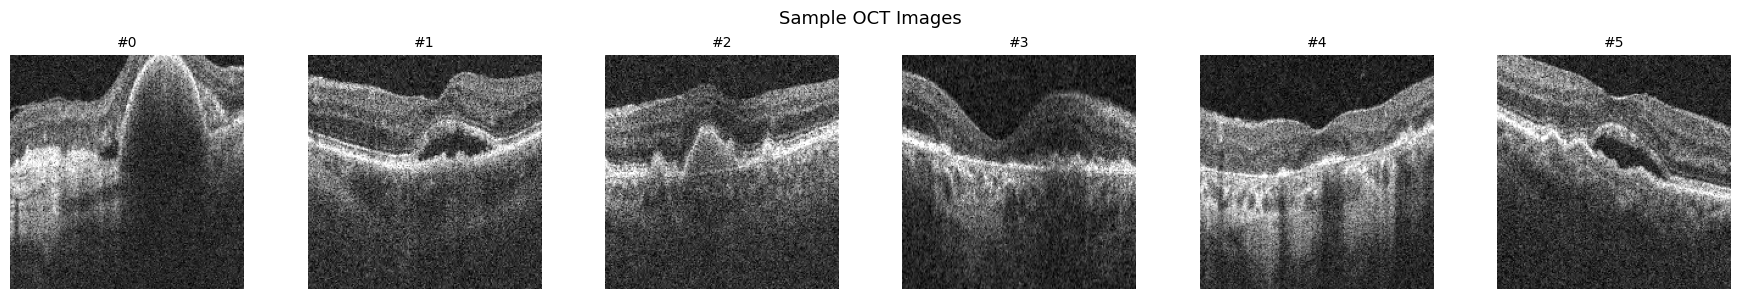

In [5]:
# =====================================================
#  샘플 OCT 이미지 로드 & 시각화
# =====================================================

image_dir = PARAMS["image_dir"]
image_paths = sorted([
    p for p in glob.glob(os.path.join(image_dir, "*.png"))
    if "README" not in os.path.basename(p)
])
print(f"{len(image_paths)} OCT images found")

def load_oct_image(path):
    """OCT 이미지를 (1, 192, 192) 텐서로 변환"""
    img = np.array(Image.open(path).convert('L'), dtype=np.float32) / 255.0
    t = torch.tensor(img).unsqueeze(0)  # (1, H, W)
    h, w = t.shape[1], t.shape[2]
    # Center crop to 192x192
    top, left = max(0, (h-192)//2), max(0, (w-192)//2)
    t = t[:, top:top+192, left:left+192]
    if t.shape[1] < 192 or t.shape[2] < 192:
        t = F.pad(t, (0, 192-t.shape[2], 0, 192-t.shape[1]))
    return t

# 시각화
n_show = min(6, len(image_paths))
fig, axes = plt.subplots(1, n_show, figsize=(3*n_show, 3))
for i in range(n_show):
    img = load_oct_image(image_paths[i])
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f"#{i}", fontsize=10)
    axes[i].axis('off')
plt.suptitle("Sample OCT Images", fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
# =====================================================
#  Pretrained 모델로 Inference 테스트
# =====================================================

test_queries = [
    "Describe the retinal layers visible in this OCT image.",
    "Are there any signs of macular pathology or AMD?",
    "Write a clinical report for this OCT scan.",
]

# 3장의 이미지에 대해 inference
n_test = min(3, len(image_paths))
test_images = [load_oct_image(image_paths[i]) for i in range(n_test)]

model.eval()
print("Generating responses with pretrained RetinaVLM...")
print("=" * 60)

for i in range(n_test):
    img = test_images[i]
    q = test_queries[i % len(test_queries)]

    responses = retinavlm.forward([img], [q], max_new_tokens=200)

    print(f"\n[Image {i}] {os.path.basename(image_paths[i])}")
    print(f"  Q: {q}")
    print(f"  A: {responses[0][:500]}")
    print("-" * 40)

Generating responses with pretrained RetinaVLM...


AttributeError: 'list' object has no attribute 'shape'

In [ ]:
# =====================================================
#  학습용 Dataset
# =====================================================

class OCTFineTuneDataset(Dataset):
    """OCT 이미지 + Q&A 데이터셋 (fine-tuning용)"""

    SAMPLE_QAS = [
        ("Describe the retinal layers visible in this OCT image.",
         "The OCT image shows well-defined retinal layers including the RNFL, GCL, INL, ONL, and RPE."),
        ("Are there any signs of macular pathology?",
         "No significant macular pathology is observed. The foveal contour appears normal."),
        ("What is the condition of the retinal pigment epithelium?",
         "The RPE appears intact and regular without signs of drusen or atrophy."),
        ("Is there any evidence of fluid accumulation?",
         "No intraretinal or subretinal fluid is detected in this OCT image."),
        ("Assess the overall quality of this OCT scan.",
         "The scan quality is adequate with good signal strength and clear layer visualization."),
        ("What AMD stage would you assign to this image?",
         "Based on the appearance, this image shows no signs of AMD and would be classified as normal."),
        ("Are there any biomarkers visible?",
         "No significant biomarkers such as drusen, fluid, or atrophy are visible."),
        ("Would you refer this patient?",
         "Based on this OCT image, no urgent referral is needed. Routine follow-up is recommended."),
    ]

    def __init__(self, image_paths, crop_size=192):
        self.image_paths = image_paths
        self.crop_size = crop_size
        print(f"Dataset: {len(self.image_paths)} images, {len(self.SAMPLE_QAS)} Q&A templates")

    def __len__(self):
        return max(len(self.image_paths), 16)

    def __getitem__(self, idx):
        img = load_oct_image(self.image_paths[idx % len(self.image_paths)])
        qa = self.SAMPLE_QAS[idx % len(self.SAMPLE_QAS)]
        return {"Image": img, "Question": qa[0], "Answer": qa[1]}


def collate_fn(batch):
    return {
        "Image": torch.stack([b["Image"] for b in batch]),
        "Question": [b["Question"] for b in batch],
        "Answer": [b["Answer"] for b in batch],
    }


dataset = OCTFineTuneDataset(image_paths)
dataloader = DataLoader(dataset, batch_size=PARAMS["batch_size"],
                        shuffle=True, collate_fn=collate_fn)
print(f"Dataloader: {len(dataloader)} batches (bs={PARAMS['batch_size']})")

In [ ]:
# =====================================================
#  Logger
# =====================================================

class Logger:
    def __init__(self, name, save_dir):
        self.dir = os.path.join(save_dir, name)
        os.makedirs(self.dir, exist_ok=True)
        self.log_path = os.path.join(self.dir, "log.jsonl")
        self.metrics = defaultdict(list)
        self.t0 = datetime.now()
        with open(os.path.join(self.dir, "params.json"), "w") as f:
            json.dump(PARAMS, f, indent=2, default=str)
        print(f"Experiment: {self.dir}")

    def log(self, step, **kw):
        elapsed = (datetime.now() - self.t0).total_seconds()
        entry = {"step": step, "sec": round(elapsed, 1), **kw}
        with open(self.log_path, "a") as f:
            f.write(json.dumps(entry) + "\n")
        for k, v in kw.items():
            self.metrics[k].append((step, v))

    def plot(self):
        n = len(self.metrics)
        if n == 0: return
        fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
        if n == 1: axes = [axes]
        for ax, (name, vals) in zip(axes, self.metrics.items()):
            steps, vs = zip(*vals)
            ax.plot(steps, vs, '-o', markersize=2)
            ax.set_title(name); ax.set_xlabel("step"); ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(self.dir, "curves.png"), dpi=100)
        plt.show()

In [ ]:
# =====================================================
#  Fine-tuning (Projection layer만 학습)
# =====================================================
# model.llama_proj 가 학습 대상 (Linear: 2048 -> 4096)
# Vision encoder + LLM은 frozen 상태 유지

# Projection layer만 unfreeze (이미 frozen 상태)
for p in model.llama_proj.parameters():
    p.requires_grad = True

trainable_params = [(n, p) for n, p in model.named_parameters() if p.requires_grad]
print(f"Trainable parameters ({len(trainable_params)}):")
for n, p in trainable_params:
    print(f"  {n}: {p.shape}")

optimizer = torch.optim.AdamW(
    [p for _, p in trainable_params],
    lr=PARAMS["learning_rate"],
    weight_decay=PARAMS["weight_decay"])

logger = Logger(PARAMS["experiment_name"], PARAMS["save_dir"])

# --- Training Loop ---
model.train()
model.visual_encoder.eval()  # Vision encoder는 eval 유지

step = 0
accum_loss = 0.0
ga = PARAMS["gradient_accumulation"]

print(f"\nTraining: {PARAMS['max_steps']} steps | bs={PARAMS['batch_size']} | ga={ga}")
print(f"Effective batch size: {PARAMS['batch_size'] * ga}")
print("-" * 60)

while step < PARAMS["max_steps"]:
    for batch in dataloader:
        if step >= PARAMS["max_steps"]:
            break

        # MiniGPT4.forward expects {Image, Question, Answer}
        batch["Image"] = batch["Image"].to(model.device, dtype=torch.float16)

        loss = model(batch)
        (loss / ga).backward()
        accum_loss += loss.item()

        if (step + 1) % ga == 0:
            nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad],
                PARAMS["max_grad_norm"])
            optimizer.step()
            optimizer.zero_grad()

        step += 1

        if step % PARAMS["log_every"] == 0:
            avg = accum_loss / PARAMS["log_every"]
            lr = optimizer.param_groups[0]["lr"]
            logger.log(step, loss=round(avg, 4), lr=lr)
            print(f"Step {step:>5}/{PARAMS['max_steps']} | loss={avg:.4f} | lr={lr:.2e}")
            accum_loss = 0.0

        if step > 0 and step % PARAMS["save_every"] == 0:
            ckpt = os.path.join(logger.dir, f"proj_step{step}.pt")
            torch.save({
                "step": step,
                "projection": model.llama_proj.state_dict(),
                "optimizer": optimizer.state_dict(),
            }, ckpt)
            print(f"  Saved: {ckpt}")

print("\nTraining complete!")
logger.plot()

In [ ]:
# =====================================================
#  Fine-tuning 후 Inference 비교
# =====================================================

model.eval()

test_queries_2 = [
    "Describe what you see in this retinal OCT image.",
    "Are there any abnormalities visible in this scan?",
    "What AMD stage would you assign and would you refer this patient?",
]

n_test = min(3, len(image_paths))
print("Fine-tuned model responses:")
print("=" * 60)

for i in range(n_test):
    img = load_oct_image(image_paths[i])
    q = test_queries_2[i % len(test_queries_2)]

    responses = retinavlm.forward([img], [q], max_new_tokens=200)

    print(f"\n[Image {i}]")
    print(f"  Q: {q}")
    print(f"  A: {responses[0][:500]}")
    print("-" * 40)

In [ ]:
# =====================================================
#  Checkpoint 로드 (이전 실험 이어하기)
# =====================================================

def load_projection_checkpoint(model, path, optimizer=None):
    ckpt = torch.load(path, map_location="cpu")
    model.llama_proj.load_state_dict(ckpt["projection"])
    if optimizer and "optimizer" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer"])
    print(f"Loaded projection weights from step {ckpt['step']}: {path}")
    return ckpt["step"]

# 사용 예시 (주석 해제):
# load_projection_checkpoint(model, "./experiments/retinavlm_finetune_v1/proj_step50.pt", optimizer)

## 실험 가이드

### 파라미터 수정

| 실험 | 변경할 곳 | 설명 |
|------|----------|------|
| Learning rate | `PARAMS["learning_rate"]` | `1e-3` ~ `1e-5` |
| Batch size | `PARAMS["batch_size"]` + `gradient_accumulation` | effective batch 조절 |
| 학습 스텝 | `PARAMS["max_steps"]` | 더 오래 학습 |
| 실험 이름 | `PARAMS["experiment_name"]` | 각 실험별 로그 분리 |

### 고급 실험

```python
# Vision encoder도 fine-tune (메모리 많이 필요)
for p in model.visual_encoder.parameters():
    p.requires_grad = True

# Perceiver projection으로 변경 (config 수정 후 재로드)
config.model.miniformer.name = "perceiver"

# RETFound vision encoder 사용
# 1. retfound.yaml의 vision_encoder config 사용
# 2. RETFound_oct_weights.pth 다운로드
# 3. config.model.vision_encoder.name = "retfound" 로 변경
```

### 가중치 다운로드 링크

- **RetinaVLM (전체)**: `RobbieHolland/RetinaVLM` (HuggingFace, 자동 다운로드)
- **RETFound OCT**: [Google Drive](https://drive.google.com/file/d/1m6s7QYkjyjJDlpEuXm7Xp3PmjN-elfW2/view)
- **RETFound GitHub**: [rmaphoh/RETFound](https://github.com/rmaphoh/RETFound)
- **Llama3 접근 신청**: [meta-llama/Meta-Llama-3-8B-Instruct](https://huggingface.co/meta-llama/Meta-Llama-3-8B-Instruct)

### HuggingFace 인증
```bash
pip install huggingface_hub
huggingface-cli login
```